In [3]:
!pip install ucimlrepo


Размер датасета: 303 наблюдений, 13 признаков

Первые 5 строк данных:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  

Целевая переменная:
   num
0    0
1    2
2    1
3    0
4    0

Информация о типах данных:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
d

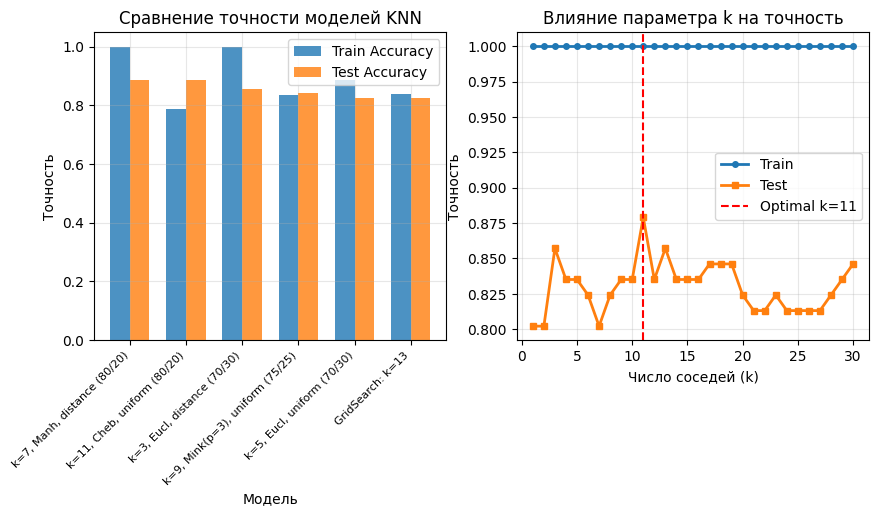

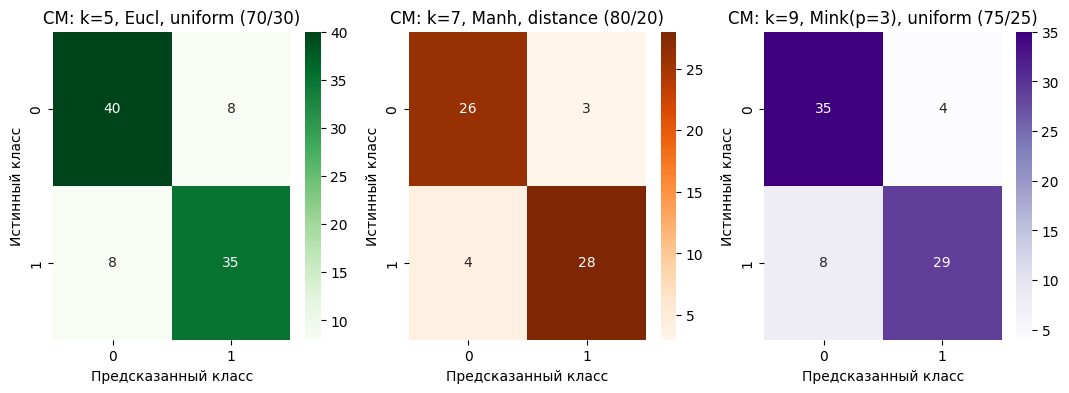

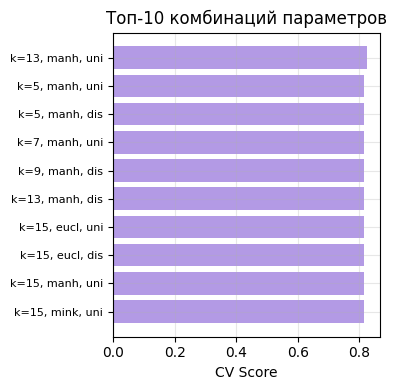

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
import warnings
warnings.filterwarnings('ignore')

heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features
y = heart_disease.data.targets

print(f"\nРазмер датасета: {X.shape[0]} наблюдений, {X.shape[1]} признаков")
print(f"\nПервые 5 строк данных:")
print(X.head())
print(f"\nЦелевая переменная:")
print(y.head())


print("\nИнформация о типах данных:")
print(X.dtypes)

print("\nСтатистическое описание данных:")
print(X.describe())

print(f"\nПропущенные значения:\n{X.isnull().sum()}")
X = X.fillna(X.median())

y_binary = (y > 0).astype(int)
print(f"\nРаспределение целевой переменной:")
print(y_binary['num'].value_counts())

# ШАГ 4: ПОДГОТОВКА ДАННЫХ ДЛЯ KNN

print("\nНезависимые переменные (13 признаков):", list(X.columns))
print("Зависимая переменная: num (наличие сердечного заболевания)")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Все признаки приведены к единому масштабу (mean=0, std=1)")

# Словарь для хранения результатов
results = []
all_predictions = {}
all_test_sets = {}


print("МОДЕЛЬ 1: k=5, Евклидово расстояние, равные веса, разбиение 70/30")

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_scaled, y_binary, test_size=0.3, random_state=42
)
print(f"Обучающая выборка: {len(X_train1)} наблюдений")
print(f"Тестовая выборка: {len(X_test1)} наблюдений")

# Создание и обучение модели
knn1 = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='uniform')
knn1.fit(X_train1, y_train1.values.ravel())

# Прогнозирование
y_pred1 = knn1.predict(X_test1)
y_train_pred1 = knn1.predict(X_train1)

# Оценка модели
train_acc1 = accuracy_score(y_train1, y_train_pred1)
test_acc1 = accuracy_score(y_test1, y_pred1)
precision1 = precision_score(y_test1, y_pred1)
recall1 = recall_score(y_test1, y_pred1)
f1_1 = f1_score(y_test1, y_pred1)
cv_scores1 = cross_val_score(knn1, X_train1, y_train1.values.ravel(), cv=5)

print(f"\nТочность на обучающей выборке: {train_acc1:.4f}")
print(f"Точность на тестовой выборке: {test_acc1:.4f}")
print(f"Precision: {precision1:.4f}")
print(f"Recall: {recall1:.4f}")
print(f"F1-measure: {f1_1:.4f}")
print(f"Перекрестная проверка (5-fold CV): {cv_scores1.mean():.4f} (+/- {cv_scores1.std():.4f})")
print("\nОтчет классификации:")
print(classification_report(y_test1, y_pred1))

results.append({
    'model': 'k=5, Eucl, uniform (70/30)',
    'k': 5,
    'metric': 'euclidean',
    'weights': 'uniform',
    'split': '70/30',
    'train_acc': train_acc1,
    'test_acc': test_acc1,
    'precision': precision1,
    'recall': recall1,
    'f1': f1_1,
    'cv_mean': cv_scores1.mean(),
    'cv_std': cv_scores1.std()
})
all_predictions['model1'] = y_pred1
all_test_sets['model1'] = y_test1

print("МОДЕЛЬ 2: k=7, Манхэттенское расстояние, взвешенное голосование, 80/20")

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_scaled, y_binary, test_size=0.2, random_state=42
)
print(f"Обучающая выборка: {len(X_train2)} наблюдений")
print(f"Тестовая выборка: {len(X_test2)} наблюдений")

knn2 = KNeighborsClassifier(n_neighbors=7, metric='manhattan', weights='distance')
knn2.fit(X_train2, y_train2.values.ravel())

y_pred2 = knn2.predict(X_test2)
y_train_pred2 = knn2.predict(X_train2)

train_acc2 = accuracy_score(y_train2, y_train_pred2)
test_acc2 = accuracy_score(y_test2, y_pred2)
precision2 = precision_score(y_test2, y_pred2)
recall2 = recall_score(y_test2, y_pred2)
f1_2 = f1_score(y_test2, y_pred2)
cv_scores2 = cross_val_score(knn2, X_train2, y_train2.values.ravel(), cv=7)

print(f"\nТочность на обучающей выборке: {train_acc2:.4f}")
print(f"Точность на тестовой выборке: {test_acc2:.4f}")
print(f"Precision: {precision2:.4f}")
print(f"Recall: {recall2:.4f}")
print(f"F1-measure: {f1_2:.4f}")
print(f"Перекрестная проверка (7-fold CV): {cv_scores2.mean():.4f} (+/- {cv_scores2.std():.4f})")
print("\nОтчет классификации:")
print(classification_report(y_test2, y_pred2))

results.append({
    'model': 'k=7, Manh, distance (80/20)',
    'k': 7,
    'metric': 'manhattan',
    'weights': 'distance',
    'split': '80/20',
    'train_acc': train_acc2,
    'test_acc': test_acc2,
    'precision': precision2,
    'recall': recall2,
    'f1': f1_2,
    'cv_mean': cv_scores2.mean(),
    'cv_std': cv_scores2.std()
})
all_predictions['model2'] = y_pred2
all_test_sets['model2'] = y_test2


print("МОДЕЛЬ 3: k=9, Минковского (p=3), равные веса, разбиение 75/25")

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_scaled, y_binary, test_size=0.25, random_state=42
)
print(f"Обучающая выборка: {len(X_train3)} наблюдений")
print(f"Тестовая выборка: {len(X_test3)} наблюдений")

knn3 = KNeighborsClassifier(n_neighbors=9, metric='minkowski', p=3, weights='uniform')
knn3.fit(X_train3, y_train3.values.ravel())

y_pred3 = knn3.predict(X_test3)
y_train_pred3 = knn3.predict(X_train3)

train_acc3 = accuracy_score(y_train3, y_train_pred3)
test_acc3 = accuracy_score(y_test3, y_pred3)
precision3 = precision_score(y_test3, y_pred3)
recall3 = recall_score(y_test3, y_pred3)
f1_3 = f1_score(y_test3, y_pred3)
cv_scores3 = cross_val_score(knn3, X_train3, y_train3.values.ravel(), cv=10)

print(f"\nТочность на обучающей выборке: {train_acc3:.4f}")
print(f"Точность на тестовой выборке: {test_acc3:.4f}")
print(f"Precision: {precision3:.4f}")
print(f"Recall: {recall3:.4f}")
print(f"F1-measure: {f1_3:.4f}")
print(f"Перекрестная проверка (10-fold CV): {cv_scores3.mean():.4f} (+/- {cv_scores3.std():.4f})")
print("\nОтчет классификации:")
print(classification_report(y_test3, y_pred3))

results.append({
    'model': 'k=9, Mink(p=3), uniform (75/25)',
    'k': 9,
    'metric': 'minkowski(p=3)',
    'weights': 'uniform',
    'split': '75/25',
    'train_acc': train_acc3,
    'test_acc': test_acc3,
    'precision': precision3,
    'recall': recall3,
    'f1': f1_3,
    'cv_mean': cv_scores3.mean(),
    'cv_std': cv_scores3.std()
})
all_predictions['model3'] = y_pred3
all_test_sets['model3'] = y_test3


print("МОДЕЛЬ 4: k=3, Евклидово расстояние, взвешенное голосование, 70/30")

knn4 = KNeighborsClassifier(n_neighbors=3, metric='euclidean', weights='distance')
knn4.fit(X_train1, y_train1.values.ravel())

y_pred4 = knn4.predict(X_test1)
y_train_pred4 = knn4.predict(X_train1)

train_acc4 = accuracy_score(y_train1, y_train_pred4)
test_acc4 = accuracy_score(y_test1, y_pred4)
precision4 = precision_score(y_test1, y_pred4)
recall4 = recall_score(y_test1, y_pred4)
f1_4 = f1_score(y_test1, y_pred4)
cv_scores4 = cross_val_score(knn4, X_train1, y_train1.values.ravel(), cv=5)

print(f"\nТочность на обучающей выборке: {train_acc4:.4f}")
print(f"Точность на тестовой выборке: {test_acc4:.4f}")
print(f"Precision: {precision4:.4f}")
print(f"Recall: {recall4:.4f}")
print(f"F1-measure: {f1_4:.4f}")
print(f"Перекрестная проверка (5-fold CV): {cv_scores4.mean():.4f} (+/- {cv_scores4.std():.4f})")
print("\nОтчет классификации:")
print(classification_report(y_test1, y_pred4))

results.append({
    'model': 'k=3, Eucl, distance (70/30)',
    'k': 3,
    'metric': 'euclidean',
    'weights': 'distance',
    'split': '70/30',
    'train_acc': train_acc4,
    'test_acc': test_acc4,
    'precision': precision4,
    'recall': recall4,
    'f1': f1_4,
    'cv_mean': cv_scores4.mean(),
    'cv_std': cv_scores4.std()
})
all_predictions['model4'] = y_pred4
all_test_sets['model4'] = y_test1


print("МОДЕЛЬ 5: k=11, Расстояние Чебышева, равные веса, разбиение 80/20")

knn5 = KNeighborsClassifier(n_neighbors=11, metric='chebyshev', weights='uniform')
knn5.fit(X_train2, y_train2.values.ravel())

y_pred5 = knn5.predict(X_test2)
y_train_pred5 = knn5.predict(X_train2)

train_acc5 = accuracy_score(y_train2, y_train_pred5)
test_acc5 = accuracy_score(y_test2, y_pred5)
precision5 = precision_score(y_test2, y_pred5)
recall5 = recall_score(y_test2, y_pred5)
f1_5 = f1_score(y_test2, y_pred5)
cv_scores5 = cross_val_score(knn5, X_train2, y_train2.values.ravel(), cv=5)

print(f"\nТочность на обучающей выборке: {train_acc5:.4f}")
print(f"Точность на тестовой выборке: {test_acc5:.4f}")
print(f"Precision: {precision5:.4f}")
print(f"Recall: {recall5:.4f}")
print(f"F1-measure: {f1_5:.4f}")
print(f"Перекрестная проверка (5-fold CV): {cv_scores5.mean():.4f} (+/- {cv_scores5.std():.4f})")
print("\nОтчет классификации:")
print(classification_report(y_test2, y_pred5))

results.append({
    'model': 'k=11, Cheb, uniform (80/20)',
    'k': 11,
    'metric': 'chebyshev',
    'weights': 'uniform',
    'split': '80/20',
    'train_acc': train_acc5,
    'test_acc': test_acc5,
    'precision': precision5,
    'recall': recall5,
    'f1': f1_5,
    'cv_mean': cv_scores5.mean(),
    'cv_std': cv_scores5.std()
})
all_predictions['model5'] = y_pred5
all_test_sets['model5'] = y_test2

print("GRID SEARCH: ПОИСК ОПТИМАЛЬНЫХ ПАРАМЕТРОВ")

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\nВыполнение Grid Search")
grid_search.fit(X_train1, y_train1.values.ravel())

print("РЕЗУЛЬТАТЫ GRID SEARCH")
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший CV score: {grid_search.best_score_:.4f}")

# Обучение лучшей модели
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test1)
y_train_pred_best = best_knn.predict(X_train1)

train_acc_best = accuracy_score(y_train1, y_train_pred_best)
test_acc_best = accuracy_score(y_test1, y_pred_best)
precision_best = precision_score(y_test1, y_pred_best)
recall_best = recall_score(y_test1, y_pred_best)
f1_best = f1_score(y_test1, y_pred_best)

print(f"\nТочность лучшей модели на обучающей выборке: {train_acc_best:.4f}")
print(f"Точность лучшей модели на тестовой выборке: {test_acc_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"F1-measure: {f1_best:.4f}")

results.append({
    'model': f"GridSearch: k={grid_search.best_params_['n_neighbors']}",
    'k': grid_search.best_params_['n_neighbors'],
    'metric': grid_search.best_params_['metric'],
    'weights': grid_search.best_params_['weights'],
    'split': '70/30',
    'train_acc': train_acc_best,
    'test_acc': test_acc_best,
    'precision': precision_best,
    'recall': recall_best,
    'f1': f1_best,
    'cv_mean': grid_search.best_score_,
    'cv_std': 0.0
})
all_predictions['best_model'] = y_pred_best
all_test_sets['best_model'] = y_test1

print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('test_acc', ascending=False)
print("\n", results_df.to_string(index=False))

print("ТРИ ЛУЧШИЕ МОДЕЛИ:")
top3 = results_df.head(3)
for idx, row in top3.iterrows():
    print(f"\n{row['model']}:")
    print(f"  - k (число соседей): {row['k']}")
    print(f"  - Метрика расстояния: {row['metric']}")
    print(f"  - Веса: {row['weights']}")
    print(f"  - Train Accuracy: {row['train_acc']:.4f}")
    print(f"  - Test Accuracy: {row['test_acc']:.4f}")
    print(f"  - Precision: {row['precision']:.4f}")
    print(f"  - Recall: {row['recall']:.4f}")
    print(f"  - F1-measure: {row['f1']:.4f}")
    print(f"  - CV Score: {row['cv_mean']:.4f}")


print("АНАЛИЗ ВЛИЯНИЯ ПАРАМЕТРА k")

k_values = range(1, 31)
train_scores = []
test_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='distance')
    knn_temp.fit(X_train1, y_train1.values.ravel())
    train_scores.append(knn_temp.score(X_train1, y_train1))
    test_scores.append(knn_temp.score(X_test1, y_test1))

optimal_k = k_values[np.argmax(test_scores)]
print(f"\nОптимальное значение k: {optimal_k}")
print(f"Максимальная точность на тесте: {max(test_scores):.4f}")


print("СОЗДАНИЕ ГРАФИКОВ ДЛЯ ОТЧЕТА")

fig1, axes1 = plt.subplots(1, 2, figsize=(10, 4))

# Сравнение точности моделей
ax = axes1[0]
models = results_df['model'][:6]
train_accs = results_df['train_acc'][:6]
test_accs = results_df['test_acc'][:6]

x = np.arange(len(models))
width = 0.35

ax.bar(x - width/2, train_accs, width, label='Train Accuracy', alpha=0.8)
ax.bar(x + width/2, test_accs, width, label='Test Accuracy', alpha=0.8)
ax.set_xlabel('Модель')
ax.set_ylabel('Точность')
ax.set_title('Сравнение точности моделей KNN')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.grid(True, alpha=0.3)

# Влияние k на точность
ax = axes1[1]
ax.plot(k_values, train_scores, 'o-', label='Train', linewidth=2, markersize=4)
ax.plot(k_values, test_scores, 's-', label='Test', linewidth=2, markersize=4)
ax.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal k={optimal_k}')
ax.set_xlabel('Число соседей (k)')
ax.set_ylabel('Точность')
ax.set_title('Влияние параметра k на точность')
ax.legend()
ax.grid(True, alpha=0.3)


# Детальный анализ лучших моделей
fig2, axes2 = plt.subplots(1, 3, figsize=(13, 4))

# Confusion Matrix - Модель 1
ax = axes2[0]
if 'model1' in all_predictions:
    cm1 = confusion_matrix(all_test_sets['model1'], all_predictions['model1'])
    sns.heatmap(cm1, annot=True, fmt='d', cmap='Greens', ax=ax)
    ax.set_title(f"CM: {results[0]['model']}")
    ax.set_ylabel('Истинный класс')
    ax.set_xlabel('Предсказанный класс')

# Confusion Matrix - Модель 2
ax = axes2[1]
if 'model2' in all_predictions:
    cm2 = confusion_matrix(all_test_sets['model2'], all_predictions['model2'])
    sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges', ax=ax)
    ax.set_title(f"CM: {results[1]['model']}")
    ax.set_ylabel('Истинный класс')
    ax.set_xlabel('Предсказанный класс')

# Confusion Matrix - Модель 3
ax = axes2[2]
if 'model3' in all_predictions:
    cm3 = confusion_matrix(all_test_sets['model3'], all_predictions['model3'])
    sns.heatmap(cm3, annot=True, fmt='d', cmap='Purples', ax=ax)
    ax.set_title(f"CM: {results[2]['model']}")
    ax.set_ylabel('Истинный класс')
    ax.set_xlabel('Предсказанный класс')


fig4, axes4 = plt.subplots(1, 1, figsize=(4, 4))

# Топ-10 комбинаций параметров
ax = axes4
top_10_results = grid_results.nlargest(10, 'mean_test_score')
param_labels = [
    f"k={row['param_n_neighbors']}, {row['param_metric'][:4]}, {row['param_weights'][:3]}"
    for _, row in top_10_results.iterrows()
]
ax.barh(range(10), top_10_results['mean_test_score'], alpha=0.7, color='mediumpurple')
ax.set_yticks(range(10))
ax.set_yticklabels(param_labels, fontsize=8)
ax.set_xlabel('CV Score')
ax.set_title('Топ-10 комбинаций параметров')
ax.grid(True, alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
